In [1]:
# Import the librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import dataset
df = pd.read_csv("Mental_Health_Student.csv")

df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [3]:
# Check the struture of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [4]:
# Check the duplicate rows
df.duplicated().sum()

np.int64(2)

In [5]:
df[df.duplicated()]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [6]:
# Drop the duplicate rows
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [7]:
# Check the missing values
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [8]:
# Summary statistics
df.describe().round(3)

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000,4998.000,4998.000,4998.000,4998.000,4998.000,4998.000
mean,20.822,5.078,171.456,3.008,1.751,6.635,6.231
std,1.737,1.654,42.860,1.637,0.668,1.222,1.278
min,18.000,1.000,62.000,0.300,-0.400,3.600,3.600
25%,19.000,3.800,140.000,1.500,1.300,5.600,5.100
50%,21.000,5.000,171.000,2.800,1.700,6.600,6.100
75%,22.000,6.300,204.000,4.200,2.200,7.500,7.100
max,24.000,8.800,273.000,8.300,4.100,9.900,9.400


In [9]:
# Description of Categorical variables
cat_col = ["Gender", "Country", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Stress_Level"]
for col in cat_col:
    describe = df[col].value_counts()
    print(f'\n Distribution of {col}')
    print(describe)


 Distribution of Gender
Gender
Male      2634
Female    2364
Name: count, dtype: int64

 Distribution of Country
Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Kuwait          1
Colombia        1
Bosnia          1
Croatia         1
Name: count, Length: 111, dtype: int64

 Distribution of Academic_Level
Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64

 Distribution of Most_Used_Platform
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

 Distribution of Purpose_Of_Use
Purpose_Of_Use
Entertainment    2551
Education        1093
Networking        793
News              561
Name: count, dtype: int64

 Distribution of Stress_Level
Stress_Lev

In [10]:
# Correlation matrix
num_col = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks", "Study_Hours", 
    "Physical_Activity_Hours", "Sleep_Hours_Per_Night", "Mental_Health_Score"]

corr_matrix = df[num_col].corr().round(4)
corr_matrix

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Age,1.0000,-0.0700,-0.0743,0.0829,0.0131,0.0885,0.1005
Avg_Daily_Usage_Hours,-0.0700,1.0000,0.9602,-0.8787,-0.6258,-0.8084,-0.8165
Daily_Unlocks,-0.0743,0.9602,1.0000,-0.8534,-0.6028,-0.7818,-0.7908
Study_Hours,0.0829,-0.8787,-0.8534,1.0000,0.5606,0.7301,0.7525
Physical_Activity_Hours,0.0131,-0.6258,-0.6028,0.5606,1.0000,0.5080,0.5216
Sleep_Hours_Per_Night,0.0885,-0.8084,-0.7818,0.7301,0.5080,1.0000,0.7665
Mental_Health_Score,0.1005,-0.8165,-0.7908,0.7525,0.5216,0.7665,1.0000


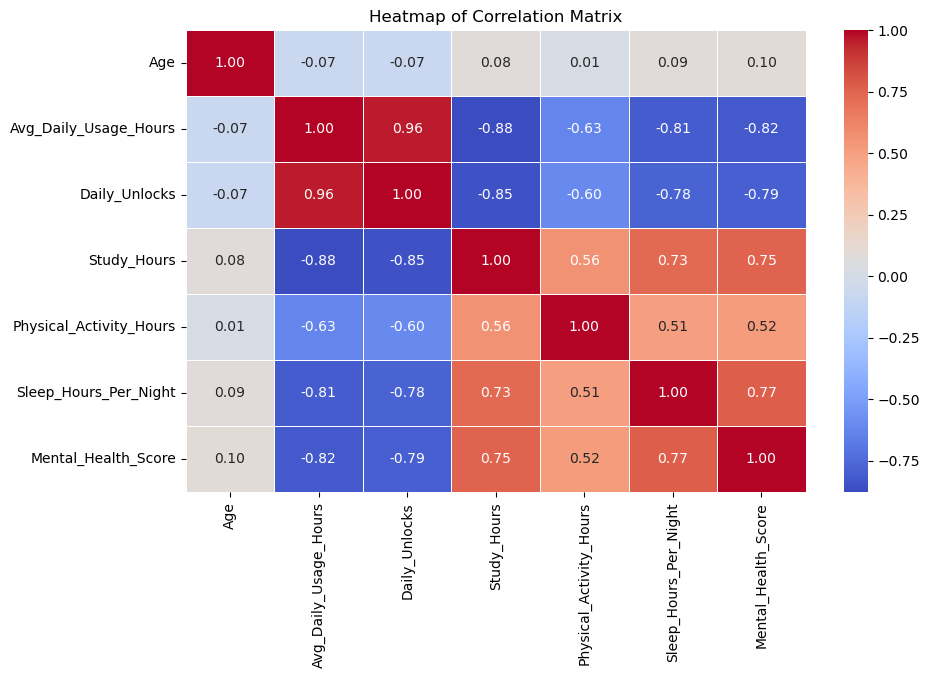

In [11]:
# Draw the heatmap 
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap of Correlation Matrix')
plt.show()